### Dataset and Task Metadata

In [1]:
from data_foundry.schema import DatasetMetadata, PredictiveMLTaskMetadata

dataset_mold = DatasetMetadata(
    unique_name="anes_voting_2026",
    dataset_year="2026",
    domain_str="social science",
    # Data Source
    dataset_source="Other",
    original_dataset_source_download_link="https://electionstudies.org/data-center/anes-time-series-cumulative-data-file/",
    download_description=r"""
No automatic download supported!

mkdir -p local-data-warehouse/anes_voting_2026/

Download the February 5, 2026 CSV version, unzip and place the .csv in local-data-warehouse/anes_voting_2026/anes_timeseries_cdf_csv_20260205.csv.
""",
    # References
    academic_reference_bibtex=r"""@misc{anes2026timeseries,
    author       = {{American National Election Studies}},
    title        = {{ANES Time Series Cumulative Data File [dataset and documentation]}},
    year         = {2026},
    month        = feb,
    note         = {February 5, 2026 version},
    howpublished = {\url{https://www.electionstudies.org}}
}
""",
    academic_reference_bibtex_key="anes2026timeseries",
    license="Use for research or statistical purposes",
    data_tags=["Non-IID", "Temporal"],
    curation_comments="""
- We remove all samples with missing pre-election data, missing post-election data or a missing target.
- We drop 327 that are missing from the last 9 years, which will be used for the test splits.
- We drop all columns with questions that appear only in one year.
- The question columns partially stem from post-election interviews. However, there is no simple way to tell which is post-election. We therefore drop all questions for which "no post IW" is listed as a reason for missing values. Some additional questions are dropped based on common sense.
- We encode gender as a categorical variable, because Other was introduced in 2016. However there are very few of these samples. This would actually require split-specific preprocessing.
- For all features, we assign " " as missing values. Most features have additional types of missingness with own codes. We keep them as categories. That means NA only is assigned if a question was missing in a survey.
- We transform only high-cardinality (>10) numeric features to numeric, and leave all other ordinal features as categorical, since they all include at least one value that is out-of-order (e.g., "Don't know", "Refused", "Not applicable", "Other", etc.).
- Although there are several ways to further preprocess features, we leave the preprocessing minimal to enable the development of models that can handle even complex preprocessing on their own.
- Note: Alternative target could be constructed using who the candidate voted for (VCF0704). This could be a multi-class target with [Democrat, Republican, Other Party, Did not vote, Voted but unknown who]. However, the last category is less useful to predict, and might introduce problems. We therefore stick to predicting whether someone voted or not.
- Note: While the data was also used in the TableShift benchmark, we define an entirely different task, with a temporal split and more features.
- Note: Some information is represented across multiple columns, e.g.,  ['VCF0009x', 'VCF0009y', 'VCF0009z', 'VCF0010x', 'VCF0010y', 'VCF0010z', 'VCF0011x', 'VCF0011y', 'VCF0011z'] all correspond to weight. We keep all of these columns, even though some might be redundant, because we want to keep the data as close to the original as possible leaving the challenge to the model.
- Note: Ideally, we would select different feature sets per data split, depending on feature availability. However, for simplicity, we just keep all features.
- Note: We considered keeping the unique respondent identifier in the data, because otherwise models that are able to reconstruct this information would unfairly benefit. However, for now we drop the identifier since it is not a desirable predictive feature for the given task, because the goal is generalization to the population, not memorizing individual behavior.
""",
)
task_mold = PredictiveMLTaskMetadata(
    target_column_name="VCF0702",
    problem_type="binary_classification",
    objective_metric_name="roc_auc",
    time_on="VCF0004",
)

## Preprocessing

In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv(dataset_mold.path / "anes_timeseries_cdf_csv_20260205.csv", low_memory=False)

df = df.loc[df["VCF0013"] == 1]
df = df.loc[df["VCF0014"] == 1]
df = df.loc[df["VCF0702"].apply(lambda x: x in ["1", "2"])] # only keep those with a valid target

# Drop if last 9 years have only one unique value
nunique_questions = df.groupby("VCF0004").nunique()
df = df.drop(columns=nunique_questions.columns[(nunique_questions.iloc[-9:]>1).sum()==0])

# Drop if a question appears only in one year
nunique_questions = df.groupby("VCF0004").nunique()
df = df.drop(columns=nunique_questions.columns[(nunique_questions>1).sum()<=2])

drop_cols = [
    # "Version", # constant (already filtered based on availability)
    # "VCF0013","VCF0014", # pre-election and post-election availability (already filtered based on availability)
    "VCF0006", "VCF0006a", # unique respondent identifiers, (might keep "VCF0006")
    # "VCF0012",  # Survey related features (already filtered based on availability)
    'VCF0015a', 'VCF0015b', 'VCF0016', 'VCF0017', "VCF0072a", 'VCF0009x', 'VCF0009y', 'VCF0009z', 'VCF0010x', 'VCF0010y',  'VCF0010z', 'VCF0011x', 'VCF0011y', 'VCF0011z', "VCF0018a", "VCF0050a", "VCF0070a", "VCF0071a", "VCF0071c", # Survey related features
    "VCF0438",  'VCF0443', 'VCF0445', 'VCF0447', 'VCF0448', 'VCF0471', 'VCF0472', 'VCF9007', # too year specific
    "VCF0704", # alternative targets
     # POST-election interview questions (selected by title and description)
     "VCF0071b", "VCF0071d", 'VCF0072b',
     "VCF9999", 'VCF0018b', 'VCF0050b', 'VCF0015b', 'VCF0070b',
     'VCF0703', 'VCF0704a', 'VCF0705', 'VCF0706', 'VCF0707', 'VCF0708', 'VCF0709', 'VCF0710', 'VCF0712', 'VCF0717', 'VCF0718', 'VCF0719', 'VCF0720', 'VCF0721', 'VCF0723', 'VCF0723a',  'VCF0724',
     'VCF0725', 'VCF0726', 'VCF0727', 'VCF0728', 'VCF0729', 'VCF0731', 'VCF0733', 'VCF0734', 'VCF0735', # post
     'VCF1014'
]

df = df.drop(columns=drop_cols)

 # POST-election interview questions (selected by whether "no Post IW" is listed as a reason for missing)
no_post_election_NA_filter = [
 'VCF0128', 'VCF0129',  
'VCF0203', 'VCF0204', 'VCF0205', 'VCF0206', 'VCF0207', 'VCF0208', 'VCF0209', 'VCF0210', 'VCF0211', 'VCF0212', 'VCF0213', 'VCF0214', 'VCF0217',
'VCF0219', 'VCF0220','VCF0223', 'VCF0225', 'VCF0226', 'VCF0227', 'VCF0228',
 'VCF0229', 'VCF0231', 'VCF0232', 'VCF0233', 'VCF0234','VCF0253', 
'VCF0312', 'VCF0313',
 'VCF0342', 'VCF0343', 'VCF0344', 'VCF0345', 'VCF0346', 'VCF0347',
 'VCF0348', 'VCF0349', 
'VCF0424', 'VCF0425', 'VCF0428',
 'VCF0501', 'VCF0502', 'VCF0502a', 'VCF0503', 'VCF0504', 'VCF0508', 'VCF0509',
 'VCF0513', 'VCF0514', 'VCF0517', 'VCF0518', 'VCF0521', 'VCF0521a', 'VCF0522', 'VCF0537', 'VCF0538',
 'VCF0541', 'VCF0542', 'VCF0549', 'VCF0550', 'VCF0604', 'VCF0605', 'VCF0606', 'VCF0608', 'VCF0609',
 'VCF0613', 'VCF0614', 'VCF0615', 'VCF0619', 'VCF0620', 'VCF0621', 'VCF0622', 'VCF0624', 'VCF0630',
 'VCF0631', 'VCF0640', 'VCF0648', 'VCF0649', 'VCF0656', 'VCF0675', 'VCF0700', 
 'VCF0736', 'VCF0737', 'VCF0740', 'VCF0741', 'VCF0742', 'VCF0744', 'VCF0745', 'VCF0748',
 'VCF0749', 'VCF0750', 'VCF0801', 'VCF0803', 'VCF0804', 'VCF0806', 'VCF0808', 'VCF0809',
 'VCF0816', 'VCF0823', 'VCF0824', 'VCF0826', 'VCF0829', 'VCF0830',
 'VCF0838','VCF0846', 'VCF0847', 'VCF0848', 'VCF0848a', 'VCF0849',
 'VCF0851', 'VCF0852', 'VCF0853', 'VCF0854', 'VCF0867', 'VCF0867a',
'VCF0873', 'VCF0875', 'VCF0875b', 'VCF0876',
 'VCF0876a', 'VCF0877', 'VCF0877a', 'VCF0878', 'VCF0879', 'VCF0879a', 'VCF0880', 'VCF0880a', 'VCF0881', 'VCF0886', 'VCF0887',
 'VCF0888', 'VCF0889', 'VCF0890', 'VCF0891', 'VCF0892', 'VCF0893', 'VCF0894',
 'VCF0900', 'VCF0900b', 'VCF0900c', 'VCF0901a', 'VCF0901b', # DO not have "no post IW" as missing, but clearly are post-IW
'VCF0902', 'VCF0903', 'VCF0904', 'VCF0905', 'VCF0906', 'VCF0907', 'VCF0908', 'VCF0909', 'VCF0972', 'VCF0973',
 'VCF0974', 'VCF0975', 'VCF0976', 'VCF0977', 'VCF0978', 'VCF0980', 'VCF0981', 'VCF0982', 'VCF0983',
 'VCF0984', 'VCF0985', 'VCF0986', 'VCF0987', 'VCF0988', 'VCF0989', 'VCF0990', 'VCF0991', 'VCF0992',
 'VCF0993', 'VCF0994',
 'VCF0995', 'VCF0996', 'VCF0997', 'VCF0998', 'VCF0999', 'VCF1000', 'VCF1001', 'VCF1002', 'VCF1003',
 'VCF1004',  'VCF1006', 'VCF1007', 'VCF1008', 'VCF1009', 'VCF1010', 'VCF1011', 'VCF1012', 'VCF1013',
 'VCF1016', 'VCF1017', 'VCF1018', 'VCF1020', 'VCF1021a', 'VCF1021b', 'VCF1022a', 'VCF1022b',
 'VCF1023a', 'VCF1023b', 'VCF1024a', 'VCF1024b', 'VCF1025a', 'VCF1025b', 'VCF1026', 'VCF1027a',
 'VCF1027b', 'VCF1028a', 'VCF1028b', 'VCF1029a', 'VCF1029b', 'VCF1030a', 'VCF1030b', 'VCF1031a',
 'VCF1031b', 'VCF1032', 'VCF1033a', 'VCF1033b', 'VCF1034a', 'VCF1034b',
'VCF1035a', 'VCF1035b', 'VCF1036a', 'VCF1036b', 'VCF1037a', 'VCF1037b', 'VCF1038', 'VCF1039a',
 'VCF1039b', 'VCF1040a', 'VCF1040b', 'VCF1041a', 'VCF1041b', 'VCF1042a', 'VCF1042b', 'VCF1043a', 'VCF1043b',
 'VCF9004', 'VCF9005', 'VCF9006',
 'VCF9012', 'VCF9013', 'VCF9014', 'VCF9015', 'VCF9016', 'VCF9017', 'VCF9018', 'VCF9021',
 'VCF9022', 'VCF9023', 'VCF9025', 'VCF9027',
 'VCF9030', 'VCF9030a', 'VCF9030b', 'VCF9030c', 'VCF9031', 'VCF9032', 'VCF9036', 'VCF9037', 'VCF9039',
 'VCF9040', 'VCF9041', 'VCF9042', 'VCF9043', 'VCF9043a',
 'VCF9046', 'VCF9047', 'VCF9048', 'VCF9049', 'VCF9050', 'VCF9054', 'VCF9055', 'VCF9056',
 'VCF9057', 'VCF9058', 'VCF9059', 'VCF9060', 'VCF9061', 'VCF9062', 'VCF9069',
 'VCF9075', 'VCF9076', 'VCF9078', 'VCF9079', 'VCF9080', 'VCF9083',
 'VCF9084', 'VCF9087', 'VCF9088', 'VCF9091', 'VCF9092', 'VCF9095',
 'VCF9096', 'VCF9099', 'VCF9101', 'VCF9104', 'VCF9106', 'VCF9109', 'VCF9111', 'VCF9114', 'VCF9116',
 'VCF9124', 'VCF9125', 'VCF9131', 'VCF9132', 'VCF9133',
 
 ]

df = df.drop(columns=no_post_election_NA_filter)

### Encode single features
# Gender
# df.loc[df["VCF0104"]==0, "VCF0104"] = np.nan
# df["VCF0104"] = df["VCF0104"].astype("category")

# Assign cat features:
cat_cols = ["VCF0110"]
for col in cat_cols:
    df[col] = df[col].astype("category")

# Assign missings:
for col in df.columns:
    df.loc[df[col] == " ", col] = np.nan

# isna_0 = ["VCF0110"]
# for col in isna_0:
#     df.loc[df[col]==0, col] = np.nan

num_cols = ['VCF0101', 'VCF0218', 'VCF0222', 'VCF0224', 'VCF0290', 'VCF0291',
       'VCF0412', 'VCF0413', 'VCF0414', 'VCF0415', 'VCF0426', 'VCF0427',
       'VCF0429', 'VCF1015', 'VCF9123', 'VCF9201', 'VCF9202', 'VCF9207',
       'VCF9208', 'VCF9240', 'VCF9267', 'VCF9268', 'VCF9269']

for col in num_cols:
    df[col] = pd.to_numeric(df[col])

# Would actually require more careful audition
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].astype("category")

print("Loaded data shape:", df.shape)
df = df.sort_values(by="VCF0004").reset_index(drop=True)

Loaded data shape: (48587, 319)


In [3]:
# feat_types = pd.read_csv("anes_feature_types_selected_columns.csv")
# feat_types

In [4]:
# missing_codes = pd.read_csv("anes_missing_codes_for_selected_features.csv")
# missing_codes.index = missing_codes.variable
# missing_codes["missing_codes"].value_counts()

In [5]:
# # These columns were manually found to be likely pre-election
# keep_cols = [
# 'VCF0070b', 'VCF0071b', 'VCF0071d', "VCF0072b",
# 'VCF0702', # target
# # 'VCF0704', # alternative target
# 'VCF0004', 'VCF0006',
#  'VCF0009x', 'VCF0009y', 'VCF0009z', 'VCF0010x', 'VCF0010y', 'VCF0010z', 'VCF0011x',
#  'VCF0011y', 'VCF0011z', 'VCF0018a', 'VCF0050a', 'VCF0070a', 'VCF0018a', 'VCF0050a',
#  'VCF0070a','VCF0071a','VCF0071c', 
# 'VCF0101', 'VCF0102', 'VCF0103', 'VCF0104', 'VCF0105a',
#  'VCF0105b', 'VCF0106', 'VCF0107', 'VCF0108', 'VCF0109', 'VCF0110', 'VCF0111', 'VCF0112',
#  'VCF0113', 'VCF0114', 'VCF0115', 'VCF0116', 'VCF0118', 'VCF0126', 'VCF0127', 'VCF0127a', 'VCF0127b',
# 'VCF0130', 'VCF0130a', 'VCF0132', 'VCF0134', 'VCF0135', 'VCF0137', 'VCF0138',
#  'VCF0138a', 'VCF0138b', 'VCF0138c', 'VCF0138d', 'VCF0140', 'VCF0140a', 'VCF0143', 'VCF0146',
#  'VCF0147', 'VCF0148', 'VCF0148a', 'VCF0149', 'VCF0150', 'VCF0151', 'VCF0152', 'VCF0154a', 'VCF0154b',
#  'VCF0155', 'VCF0156','VCF0157', 'VCF0170d',  
# 'VCF0218','VCF0222', 'VCF0224', 
#  'VCF0290', 'VCF0291', 'VCF0301', 'VCF0302', 'VCF0303', 'VCF0305',  
# 'VCF0310', 'VCF0311', 
#  'VCF0314',  'VCF0315',
#  'VCF0316', 'VCF0317', 'VCF0318', 'VCF0319', 'VCF0320', 'VCF0321', 'VCF0322', 'VCF0323', 'VCF0324',
#  'VCF0338', 'VCF0339', 'VCF0341', 
#  'VCF0350', 'VCF0351', 'VCF0353', 'VCF0354', 'VCF0355', 'VCF0356', 'VCF0357',
#  'VCF0358', 'VCF0359', 'VCF0360', 'VCF0361', 'VCF0362', 'VCF0365', 'VCF0366', 'VCF0367',
#  'VCF0368', 'VCF0369', 'VCF0370', 'VCF0371', 'VCF0372', 'VCF0373', 'VCF0374', 'VCF0375a', 'VCF0375b',
#  'VCF0376a', 'VCF0376b', 'VCF0377a', 'VCF0377b', 'VCF0378a', 'VCF0378b', 'VCF0379a', 'VCF0379b',
#  'VCF0380', 'VCF0381a', 'VCF0381b', 'VCF0382a', 'VCF0382b', 'VCF0383a', 'VCF0383b', 'VCF0384a',
#  'VCF0384b', 'VCF0385a', 'VCF0385b', 'VCF0386', 'VCF0387a', 'VCF0387b', 'VCF0388a', 'VCF0388b',
#  'VCF0389a', 'VCF0389b', 'VCF0390a', 'VCF0390b', 'VCF0391a', 'VCF0391b', 'VCF0392', 'VCF0393a',
#  'VCF0393b', 'VCF0394a', 'VCF0394b', 'VCF0395a', 'VCF0395b', 'VCF0396a', 'VCF0396b', 'VCF0397a',
#  'VCF0397b', 'VCF0401', 'VCF0402', 'VCF0403', 'VCF0404', 'VCF0405', 'VCF0406', 'VCF0407', 'VCF0408',
#  'VCF0409', 'VCF0410', 'VCF0411', 'VCF0412', 'VCF0413', 'VCF0414', 'VCF0415', 
#  'VCF0426', 'VCF0427', 
#  'VCF0429',
#  'VCF0450', 'VCF0451', 'VCF0475',  'VCF0476a', 'VCF0476b', 'VCF0477a', 'VCF0477b', 'VCF0478a', 'VCF0478b', 'VCF0479a', 'VCF0479b', 'VCF0480a',
#  'VCF0480b', 'VCF0481', 'VCF0482a', 'VCF0482b', 'VCF0483a', 'VCF0483b', 'VCF0484a', 'VCF0484b',
#  'VCF0485a', 'VCF0485b', 'VCF0486a', 'VCF0486b', 'VCF0487', 'VCF0488a', 'VCF0488b', 'VCF0489a',
#  'VCF0489b', 'VCF0490a', 'VCF0490b', 'VCF0491a', 'VCF0491b', 'VCF0492a', 'VCF0492b', 'VCF0493',
#  'VCF0494a', 'VCF0494b', 'VCF0495a', 'VCF0495b', 'VCF0496a', 'VCF0496b', 'VCF0497a', 'VCF0497b',
#  'VCF0498a', 'VCF0498b', 
#  'VCF0713', 'VCF0714', 
#  'VCF0834', 'VCF0839', 'VCF0842', 'VCF0843', 'VCF0850',
#  'VCF0870', 'VCF0871', 'VCF0872',
#  'VCF1005',
# 'VCF1014', 'VCF1015',
# 'VCF9001', 'VCF9002', 'VCF9009',
# 'VCF9028', 'VCF9029', 'VCF9033', 'VCF9035',
# 'VCF9044', 'VCF9044a', 'VCF9045',
# 'VCF9073', 'VCF9077', 'VCF9081', 'VCF9085', 'VCF9086', 'VCF9089', 'VCF9093', 'VCF9094',
# 'VCF9122', 'VCF9123',
# 'VCF9201', 'VCF9202', 'VCF9203', 'VCF9204', 'VCF9205', 'VCF9206', 'VCF9207', 'VCF9208', 'VCF9209',
#  'VCF9210', 'VCF9211', 'VCF9212', 'VCF9213', 'VCF9214', 'VCF9215', 'VCF9216', 'VCF9217', 'VCF9218', 'VCF9219', 'VCF9220', 'VCF9221',
#  'VCF9222', 'VCF9223', 'VCF9224', 'VCF9225', 'VCF9226', 'VCF9227', 'VCF9228', 'VCF9229', 'VCF9230',
#  'VCF9231', 'VCF9232', 'VCF9233', 'VCF9234', 'VCF9235', 'VCF9236', 'VCF9237', 'VCF9238', 'VCF9239',
#  'VCF9240', 'VCF9241', 'VCF9242', 'VCF9243', 'VCF9244', 'VCF9245', 'VCF9246', 'VCF9247', 'VCF9248',
#  'VCF9249', 'VCF9250', 'VCF9251', 'VCF9252', 'VCF9253', 'VCF9254', 'VCF9255', 'VCF9256', 'VCF9257',
#  'VCF9258', 'VCF9259', 'VCF9260', 'VCF9261', 'VCF9262', 'VCF9263', 'VCF9264', 'VCF9265', 'VCF9266',
#  'VCF9267', 'VCF9268', 'VCF9269', 'VCF9270', 'VCF9271', 'VCF9272', 'VCF9273', 'VCF9274', 'VCF9275',
#  'VCF9277', 'VCF9278', 'VCF9279', 'VCF9280', 'VCF9281', 'VCF9282'
# ]

# print(f"Left: {len([i for i in df.columns if i not in keep_cols])}")
# sorted(list([i for i in df.columns if i not in keep_cols]))[:30]

In [6]:
# pd.crosstab(df["VCF0702"], df["VCF0704"])

In [7]:
# Possible alternative target: who the candidate voted for (VCF0704)
# df["vote_outcome"] = ""
# df.loc[df["VCF0704"] == "1", "vote_outcome"] = "Democrat"
# df.loc[df["VCF0704"] == "2", "vote_outcome"] = "Republican"
# df.loc[df["VCF0704"] == "3", "vote_outcome"] = "Other Party"
# df.loc[df["VCF0702"] == "1", "vote_outcome"] = "Did not vote"
# df.loc[np.logical_and(df["VCF0702"] == "2", df["VCF0704"]=="0"), "vote_outcome"] = "Voted, unknown who"
# df["vote_outcome"].value_counts()
# pd.crosstab(df["VCF0004"], df["vote_outcome"])

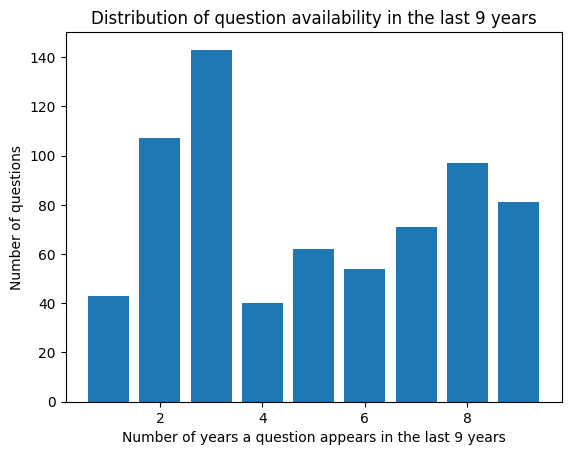

In [8]:
import matplotlib.pyplot as plt
# Might consider filtering columns appearing only in one year of the test sets
# nunique_questions = df.groupby("VCF0004").nunique()
# Of occurrence of questions:
plt.bar(range(1, 10), [sum((nunique_questions.iloc[-9:]>1).sum()==cnt) for cnt in range(1, 10)])
plt.xlabel("Number of years a question appears in the last 9 years")
plt.ylabel("Number of questions")
plt.title("Distribution of question availability in the last 9 years")
plt.show()

## Data Checks

In [9]:
from data_foundry import dataset_checks
df_head, summary, numeric_stats, cat_stats, target_df = dataset_checks.run_all_checks(
    data=df,
    classification=task_mold.is_classification,
    target_feature=task_mold.target_column_name,
    print_report=False, # In notebook...
)


#### Dataset Overview
Rows: 48,587
Columns: 319
Use sampling: False (sample size: 48,587)
Get row duplicates (staged, merged)...
Using top-10 columns for initial filtering: ['VCF0494a', 'VCF0495a', 'VCF0482a', 'VCF0483a', 'VCF0488a', 'VCF0476a', 'VCF0496a', 'VCF0489a', 'VCF0477a', 'VCF0393a']
Rows remaining as candidates after top-10 filter: 36,085 (of 48,587)

#### Duplicate Report
Total duplicate rows: 156 (0.32% of dataset)
Duplicate rows ignoring target: 186 (0.38% of dataset)
Get column duplicates...
Duplicate columns: 0 (0.00% of columns)

Data quality checks completed.


In [10]:
# Sample Rows
df_head

,VCF0004,VCF0101,VCF0102,VCF0103,VCF0104,VCF0105a,VCF0105b,VCF0106,VCF0107,VCF0108,VCF0109,VCF0110,VCF0111,VCF0112,VCF0113,VCF0114,VCF0115,VCF0116,VCF0118,VCF0126,VCF0127,VCF0127a,VCF0127b,VCF0130,VCF0130a,VCF0132,VCF0134,VCF0135,VCF0137,VCF0138,VCF0138a,VCF0138b,VCF0138c,VCF0138d,VCF0140,VCF0140a,VCF0143,VCF0146,VCF0147,VCF0148,VCF0148a,VCF0149,VCF0150,VCF0151,VCF0152,VCF0154a,VCF0154b,VCF0155,VCF0156,VCF0157,VCF0170d,VCF0218,VCF0222,VCF0224,VCF0290,VCF0291,VCF0301,VCF0302,VCF0303,VCF0305,VCF0310,VCF0311,VCF0314,VCF0315,VCF0316,VCF0317,VCF0318,VCF0319,VCF0320,VCF0321,VCF0322,VCF0323,VCF0324,VCF0338,VCF0339,VCF0341,VCF0350,VCF0351,VCF0353,VCF0354,VCF0355,VCF0356,VCF0357,VCF0358,VCF0359,VCF0360,VCF0361,VCF0362,VCF0365,VCF0366,VCF0367,VCF0368,VCF0369,VCF0370,VCF0371,VCF0372,VCF0373,VCF0374,VCF0375a,VCF0375b,VCF0376a,VCF0376b,VCF0377a,VCF0377b,VCF0378a,VCF0378b,VCF0379a,VCF0379b,VCF0380,VCF0381a,VCF0381b,VCF0382a,VCF0382b,VCF0383a,VCF0383b,VCF0384a,VCF0384b,VCF0385a,VCF0385b,VCF0386,VCF0387a,VCF0387b,VCF0388a,VCF0388b,VCF0389a,VCF0389b,VCF0390a,VCF0390b,VCF0391a,VCF0391b,VCF0392,VCF0393a,VCF0393b,VCF0394a,VCF0394b,VCF0395a,VCF0395b,VCF0396a,VCF0396b,VCF0397a,VCF0397b,VCF0401,VCF0402,VCF0403,VCF0404,VCF0405,VCF0406,VCF0407,VCF0408,VCF0409,VCF0410,VCF0411,VCF0412,VCF0413,VCF0414,VCF0415,VCF0426,VCF0427,VCF0429,VCF0450,VCF0451,VCF0475,VCF0476a,VCF0476b,VCF0477a,VCF0477b,VCF0478a,VCF0478b,VCF0479a,VCF0479b,VCF0480a,VCF0480b,VCF0481,VCF0482a,VCF0482b,VCF0483a,VCF0483b,VCF0484a,VCF0484b,VCF0485a,VCF0485b,VCF0486a,VCF0486b,VCF0487,VCF0488a,VCF0488b,VCF0489a,VCF0489b,VCF0490a,VCF0490b,VCF0491a,VCF0491b,VCF0492a,VCF0492b,VCF0493,VCF0494a,VCF0494b,VCF0495a,VCF0495b,VCF0496a,VCF0496b,VCF0497a,VCF0497b,VCF0498a,VCF0498b,VCF0702,VCF0713,VCF0714,VCF0834,VCF0839,VCF0842,VCF0843,VCF0850,VCF0870,VCF0871,VCF0872,VCF1005,VCF1015,VCF9001,VCF9002,VCF9009,VCF9028,VCF9029,VCF9033,VCF9035,VCF9044,VCF9044a,VCF9045,VCF9073,VCF9077,VCF9081,VCF9085,VCF9086,VCF9089,VCF9093,VCF9094,VCF9122,VCF9123,VCF9201,VCF9202,VCF9203,VCF9204,VCF9205,VCF9206,VCF9207,VCF9208,VCF9209,VCF9210,VCF9211,VCF9212,VCF9213,VCF9214,VCF9215,VCF9216,VCF9217,VCF9218,VCF9219,VCF9220,VCF9221,VCF9222,VCF9223,VCF9224,VCF9225,VCF9226,VCF9227,VCF9228,VCF9229,VCF9230,VCF9231,VCF9232,VCF9233,VCF9234,VCF9235,VCF9236,VCF9237,VCF9238,VCF9239,VCF9240,VCF9241,VCF9242,VCF9243,VCF9244,VCF9245,VCF9246,VCF9247,VCF9248,VCF9249,VCF9250,VCF9251,VCF9252,VCF9253,VCF9254,VCF9255,VCF9256,VCF9257,VCF9258,VCF9259,VCF9260,VCF9261,VCF9262,VCF9263,VCF9264,VCF9265,VCF9266,VCF9267,VCF9268,VCF9269,VCF9270,VCF9271,VCF9272,VCF9273,VCF9274,VCF9275,VCF9277,VCF9278,VCF9279,VCF9280,VCF9281,VCF9282
0,1948.0,NaN,3.0,7.0,2.0,1,1,1,NaN,NaN,NaN,3,NaN,NaN,NaN,5,NaN,NaN,NaN,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1948.0,NaN,6.0,8.0,1.0,1,1,1,NaN,NaN,NaN,1,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,2,NaN,NaN,Na

In [11]:
# Feature Summary
summary

,index,dtype,n_missing,pct_missing,n_unique,examples
0,VCF0385a,category,48345.0,99.50,115.0,"931, 981, 805, 801, 906, 986, 602, 606, 1107, 838"
1,VCF0385b,category,48345.0,99.50,9.0,"33, 32, 34, 35, 31, 12, 40, 11, 24"
2,VCF0391a,category,48323.0,99.46,100.0,"601, 806, 801, 1101, 1106, 609, 901, 934, 837, 835"
3,VCF0391b,category,48323.0,99.46,9.0,"33, 34, 32, 31, 12, 35, 11, 40, 23"
4,VCF0397a,category,48235.0,99.28,144.0,"1209, 907, 1206, 1234, 987, 933, 916, 964, 1027, 939"
5,VCF0397b,category,48235.0,99.28,10.0,"33, 35, 34, 32, 31, 12, 11, 40, 21, 24"
6,VCF0379a,category,48201.0,99.21,122.0,"915, 801, 1233, 906, 1229, 986, 805, 1205, 133, 1213"
7,VCF0379b,category,48201.0,99.21,9.0,"33, 35, 32, 34, 12, 11, 31, 40, 23"
8,VCF0486a,category,48023.0,98.84,161.0,"801, 402, 702, 446, 505, 304, 986, 1107, 504, 216"
9,VCF0486b,category,48023.0,98.84,11.0,"33, 23, 32, 34, 24, 21, 31, 22, 40, 35"


In [12]:
# Numeric Feature Statistics
numeric_stats

,count,mean,std,min,max
VCF0004,48587.0,1997.461790,22.898681,1948.0,2024.0
VCF0101,48011.0,47.544354,18.233628,0.0,99.0
VCF0102,48587.0,3.807109,1.794088,0.0,7.0
VCF0103,48587.0,4.040937,1.732856,0.0,8.0
VCF0104,48587.0,1.543870,0.503134,0.0,3.0
VCF0218,35211.0,53.738746,29.612215,-8.0,99.0
VCF0222,6484.0,56.710056,21.623968,0.0,99.0
VCF0224,35211.0,48.016472,29.392507,-8.0,99.0
VCF0290,30257.0,75.310275,150.682162,0.0,999.0
VCF0291,30257.0,79.665962,157.415397,2.0,999.0


In [13]:
# Categorical Feature Statistics
cat_stats

value  count    pct
column   rank                     
VCF0105a 1         1  36812  75.77
         2         2   5453  11.22
         3         5   3904   8.04
         4         6    901   1.85
         5         3    806   1.66
VCF0105b 1         1  36812  75.77
         2         2   5453  11.22
         3         3   3904   8.04
         4         4   2105   4.33
         5         9    285   0.59
VCF0106  1         1  36812  75.77
         2         3   6009  12.37
         3         2   5453  11.22
         4         9    285   0.59
         5         0     28   0.06
VCF0107  1         7  32609  67.11
         2      <NA>  12032  24.76
         3         1   1999   4.11
         4         3   1287   2.65
         5         2    378   0.78
VCF0108  1         2  32564  67.02
         2      <NA>  12032  24.76
         3         1   3798   7.82
         4         9    137   0.28
         5         8     53   0.11
VCF0109  1      <NA>  30716  63.22
         2       877   4053   8.34
         3       290   2098   4.32
         4       862   1574   3.24
         5       190   1399   2.88
VCF0110  1         2  16797  34.57
         2         4  13748  28.30
         3         3  12799  26.34
         4         1   4838   9.96
         5         0    405   0.83
VCF0111  1      <NA>  26620  54.79
         2         3   8272  17.03
         3         2   7553  15.55
         4         1   5450  11.22
         5         0    692   1.42
VCF0112  1         3  17175  35.35
         2         2  12499  25.72
         3         4   9574  19.70
         4         1   8763  18.04
         5      <NA>    576   1.19
VCF0113  1         2  30042  61.83
         2         1  13015  26.79
         3      <NA>   5530  11.38
VCF0114  1         3  14794  30.45
         2         4  12178  25.06
         3         1   7760  15.97
         4         2   7474  15.38
         5         0   2566   5.28
VCF0115  1      <NA>  25554  52.59
         2         3   6801  14.00
         3         1   5430  11.18
         4         6   4607   9.48
         5         2   3949   8.13
VCF0116  1         1  24531  50.49
         2      <NA>   7840  16.14
         3         5   7789  16.03
         4         7   3513   7.23
         5         6   1639   3.37
VCF0118  1         1  28714  59.10
         2         3   8372  17.23
         3         4   5810  11.96
         4         2   3829   7.88
         5         5    938   1.93
VCF0126  1      <NA>  28174  57.99
         2         3   7059  14.53
         3         5   5358  11.03
         4         1   3969   8.17
         5         0   1444   2.97
VCF0127  1         2  39469  81.23
         2         1   8677  17.86
         3         0    441   0.91
VCF0127a 1         0  23914  49.22
         2      <NA>  20382  41.95
         3        11   2265   4.66
         4        12   1177   2.42
         5        13    393   0.81
VCF0127b 1         0  34996  72.03
         2      <NA>   5530  11.38
         3         1   4212   8.67
         4         2   3057   6.29
         5         3    589   1.21
VCF0130  1         5  12005  24.71
         2         1   8802  18.12
         3      <NA>   7840  16.14
         4         4   7186  14.79
         5         2   4681   9.63
VCF0130a 1      <NA>  17201  35.40
         2         5   6963  14.33
         3         9   6460  13.30
         4         4   4500   9.26
         5         2   3600   7.41
VCF0132  1      <NA>  30436  62.64
         2       113   1197   2.46
         3       171   1113   2.29
         4       149   1045   2.15
         5       123    903   1.86
VCF0134  1      <NA>  28154  57.95
         2         2  13306  27.39
         3         1   6928  14.26
         4         9    184   0.38
         5         8     15   0.03
VCF0135  1      <NA>  29768  61.27
         2         2  14995  30.86
         3         1   3658   7.53
         4         9    151   0.31
         5         8     15   0.03
VCF0137  1      <NA>  39610  81.52
         2         3   25

In [14]:
# Target Distribution
target_df

,count,pct
VCF0702,,
2,37880,77.96
1,10707,22.04


## Task Curation

In [15]:
from data_foundry.schema import PredictiveMLSplitsMetadata

n_repeats = 3
n_splits = 3

date_col = task_mold.time_on
target_col = task_mold.target_column_name

df = df.sort_values(by=date_col).reset_index(drop=True)

# New approach: We define points in time
test_sets_year = df["VCF0004"].sort_values().unique()[-n_repeats*n_splits:][::-1]

used_in_train = set()
used_in_test = set()
used_data = set()

splits = {}
for split, year in enumerate(test_sets_year):

    train_idx = df.loc[df[date_col] < year].index.tolist()
    test_idx = df.loc[df[date_col] == year].index.tolist()

    splits[split] = {0: [train_idx, test_idx]}

    used_in_train.update(train_idx)
    used_in_test.update(test_idx)
    used_data.update(train_idx)
    used_data.update(test_idx)

    print(f"\n=== Step {split} ===")
    print("Train size:", len(train_idx), "| Test size:", len(test_idx))
    print("Train target mean:", df.loc[train_idx, target_col].value_counts(normalize=True).iloc[0])
    print("Test target mean:", df.loc[test_idx, target_col].value_counts(normalize=True).iloc[0])

    assert len(set(train_idx).intersection(set(test_idx)))==0, "Train and test indices overlap!"

print(f"{len(used_data)/df.shape[0]:.4f} of the samples are used.")
print(f"{len(used_in_train)/df.shape[0]:.4f} of the samples are used in training")
print(f"{len(used_in_test)/df.shape[0]:.4f} of the samples are used in testing.")

splits_mold = PredictiveMLSplitsMetadata(
    splits_comment="We use each of the last 9 years once as test data, using all prior data as train data.",
    splits=splits,
    time_horizon=1,
    time_horizon_unit="years",
)


=== Step 0 ===
Train size: 43633 | Test size: 4954
Train target mean: 0.7737492265028763
Test target mean: 0.8314493338716189

=== Step 1 ===
Train size: 36191 | Test size: 7442
Train target mean: 0.7559337956950624
Test target mean: 0.8603869927438861

=== Step 2 ===
Train size: 32543 | Test size: 3648
Train target mean: 0.7527271609870018
Test target mean: 0.7845394736842105

=== Step 3 ===
Train size: 27055 | Test size: 5488
Train target mean: 0.7434485307706524
Test target mean: 0.798469387755102

=== Step 4 ===
Train size: 24953 | Test size: 2102
Train target mean: 0.7418346491403839
Test target mean: 0.7626070409134158

=== Step 5 ===
Train size: 23887 | Test size: 1066
Train target mean: 0.7399003642148448
Test target mean: 0.7851782363977486

=== Step 6 ===
Train size: 22543 | Test size: 1344
Train target mean: 0.7413387747859645
Test target mean: 0.7157738095238095

=== Step 7 ===
Train size: 20989 | Test size: 1554
Train target mean: 0.7399113821525561
Test target mean: 0.76

## Export

In [16]:
from data_foundry.curation_container import CuratedContainer
curated_data = CuratedContainer(
    dataset=df,
    dataset_metadata=dataset_mold,
    task_metadata=task_mold,
    experiment_metadata=splits_mold,
 )
curated_data.save()
print(curated_data.uuid)
print(curated_data.checksum)

Calculating checksum for curated container...
Saving curated container to anes_voting_2026/019db4ba-6124-7a56-a0b5-9df8811adc2f
019db4ba-6124-7a56-a0b5-9df8811adc2f
3045631e0e061336e2e991c79d483cd76ba63c61a609fa2cd1d12ae8c8c9c12e
